In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


In [67]:
match_data = pd.read_csv("results.csv", parse_dates=["date"])



In [157]:
goalscorers = pd.read_csv("goalscorers.csv", parse_dates=["date"])

In [6]:
match_data["city"].value_counts().head(20)

city
Kuala Lumpur    737
Bangkok         579
Doha            552
London          441
Budapest        433
Kuwait City     375
Montevideo      372
Vienna          361
Oslo            356
Copenhagen      354
Glasgow         353
Buenos Aires    331
Dublin          322
Santiago        321
Belfast         319
Nairobi         316
Jakarta         311
Lima            307
Seoul           307
Cairo           298
Name: count, dtype: int64

In [73]:
match_data['match_id'] = (
    match_data['date'].astype(str) + '_' +
    match_data['home_team'] + '_' +
    match_data['away_team']
)

goalscorers['match_id'] = (
    goalscorers['date'].astype(str) + '_' +
    goalscorers['home_team'] + '_' +
    goalscorers['away_team']
)

goalscorers_count = goalscorers.groupby(['match_id', 'team']).size().reset_index(name='recorded_goals')

match_home = match_data[['match_id', 'date', 'home_team', 'away_team',
                         'home_score', 'away_score']].copy()
match_home['team'] = match_home['home_team']
match_home['official_goals'] = match_home['home_score']

match_away = match_data[['match_id', 'date', 'home_team', 'away_team',
                         'home_score', 'away_score']].copy()
match_away['team'] = match_away['away_team']
match_away['official_goals'] = match_away['away_score']

match_combine = pd.concat([
    match_home[['match_id', 'date', 'team', 'official_goals', 'home_team', 'away_team', 'home_score', 'away_score']],
    match_away[['match_id', 'date', 'team', 'official_goals', 'home_team', 'away_team', 'home_score', 'away_score']]
])

comparison = match_combine.merge(
    goalscorers_count,
    on=['match_id', 'team'],
    how='left'
)

comparison['recorded_goals'] = comparison['recorded_goals'].fillna(0).astype(int)

comparison['missing_goals'] = comparison['official_goals'] - comparison['recorded_goals']

comparison.head



<bound method NDFrame.head of                                      match_id       date      team  \
0                 1872-11-30_Scotland_England 1872-11-30  Scotland   
1                 1873-03-08_England_Scotland 1873-03-08   England   
2                 1874-03-07_Scotland_England 1874-03-07  Scotland   
3                 1875-03-06_England_Scotland 1875-03-06   England   
4                 1876-03-04_Scotland_England 1876-03-04  Scotland   
...                                       ...        ...       ...   
97341  2025-10-14_Republic of Ireland_Armenia 2025-10-14   Armenia   
97342              2025-10-14_Estonia_Moldova 2025-10-14   Moldova   
97343                 2025-10-14_Italy_Israel 2025-10-14    Israel   
97344               2025-10-14_Andorra_Serbia 2025-10-14    Serbia   
97345               2025-10-14_Latvia_England 2025-10-14   England   

       official_goals            home_team away_team  home_score  away_score  \
0                   0             Scotland   Engl

In [3]:
team_stats_new = pd.read_csv('teams_summary.csv')
team_stats_new.head(10)

,name,home_goals,away_goals,total_goals,home_wins,away_wins,total_wins,home_draws,away_draws,total_draws,...,total_losses,win_rate,win_percentage,goals_conceded_home,goals_conceded_away,goals_conceded,games_played,avg_goals_per_game,avg_goals_conceded_per_game,goal_difference
0,Abkhazia,39.0,12.0,51.0,11.0,3.0,14.0,8.0,5.0,13.0,...,5.0,0.437500,0.640625,13.0,13.0,26.0,32.0,1.593750,0.812500,27.0
1,Afghanistan,55.0,85.0,140.0,18.0,17.0,35.0,11.0,21.0,32.0,...,75.0,0.246479,0.359155,70.0,218.0,288.0,142.0,0.985915,2.028169,-30.0
2,Albania,239.0,136.0,375.0,78.0,31.0,109.0,48.0,36.0,84.0,...,199.0,0.278061,0.385204,227.0,355.0,582.0,392.0,0.956633,1.484694,103.0
3,Alderney,20.0,53.0,73.0,1.0,4.0,5.0,1.0,1.0,2.0,...,128.0,0.037037,0.044444,199.0,421.0,620.0,135.0,0.540741,4.592593,-33.0
4,Algeria,649.0,264.0,913.0,198.0,77.0,275.0,82.0,76.0,158.0,...,166.0,0.459098,0.590985,288.0,318.0,606.0,599.0,1.524207,1.011686,385.0
5,Ambazonia,NaN,3.0,3.0,NaN,0.0,0.0,NaN,1.0,1.0,...,5.0,0.000000,0.083333,NaN,17.0,17.0,6.0,0.500000,2.833333,NaN
6,American Samoa,18.0,13.0,31.0,3.0,1.0,4.0,2.0,0.0,2.0,...,47.0,0.075472,0.094340,145.0,201.0,346.0,53.0,0.584906,6.528302,5.0
7,Andalusia,23.0,2.0,25.0,7.0,1.0,8.0,4.0,0.0,4.0,...,1.0,0.615385,0.769231,13.0,1.0,14.0,13.0,1.923077,1.076923,21.0
8,Andorra,42.0,31.0,73.0,11.0,2.0,13.0,16.0,14.0,30.0,...,179.0,0.058559,0.126126,225.0,307.0,532.0,222.0,0.328829,2.396396,11.0
9,Angola,286.0,174.0,460.0,96.0,43.0,139.0,63.0,80.0,143.0,...,124.0,0.342365,0.518473,167.0,252.0,419.0,406.0,1.133005,1.032020,112.0


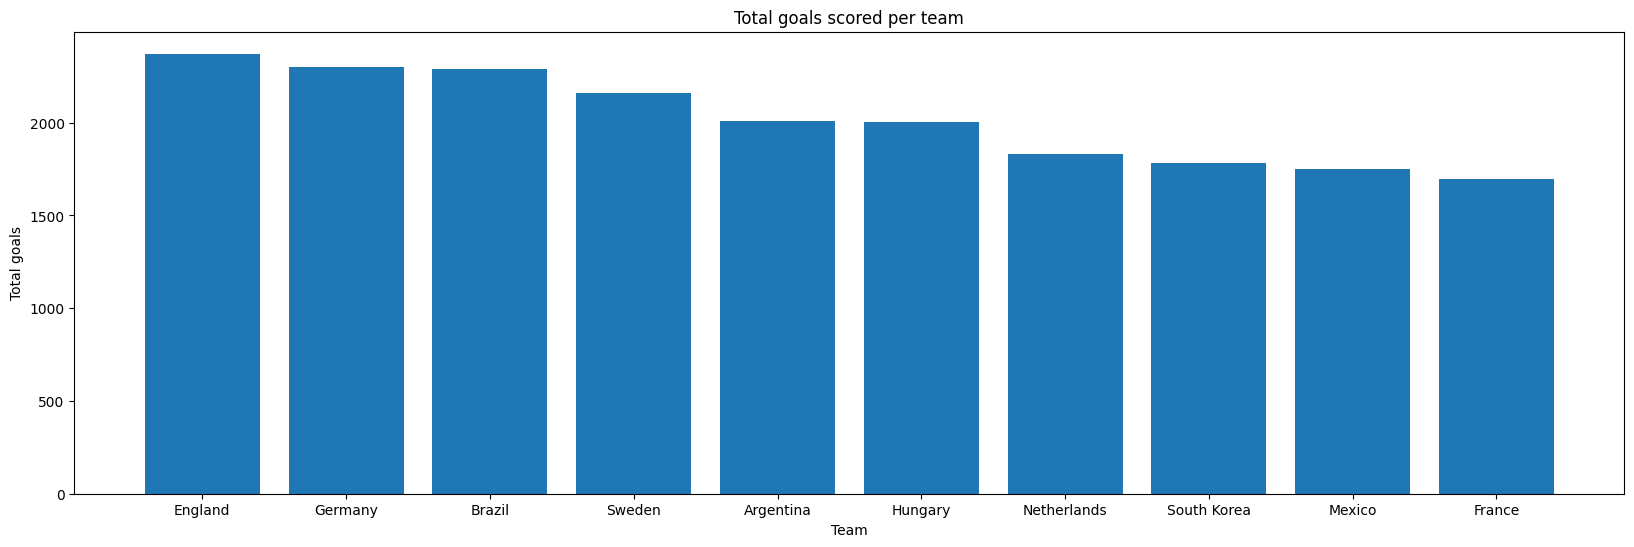

In [54]:
total_goals_per_team = team_stats_new.groupby(
    team_stats_new['name'])['total_goals'].sum()
total_goals_per_team = total_goals_per_team.sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(total_goals_per_team.index, total_goals_per_team)
ax.set_title('Total goals scored per team')
ax.set_xlabel('Team')
ax.set_ylabel('Total goals')
plt.show()


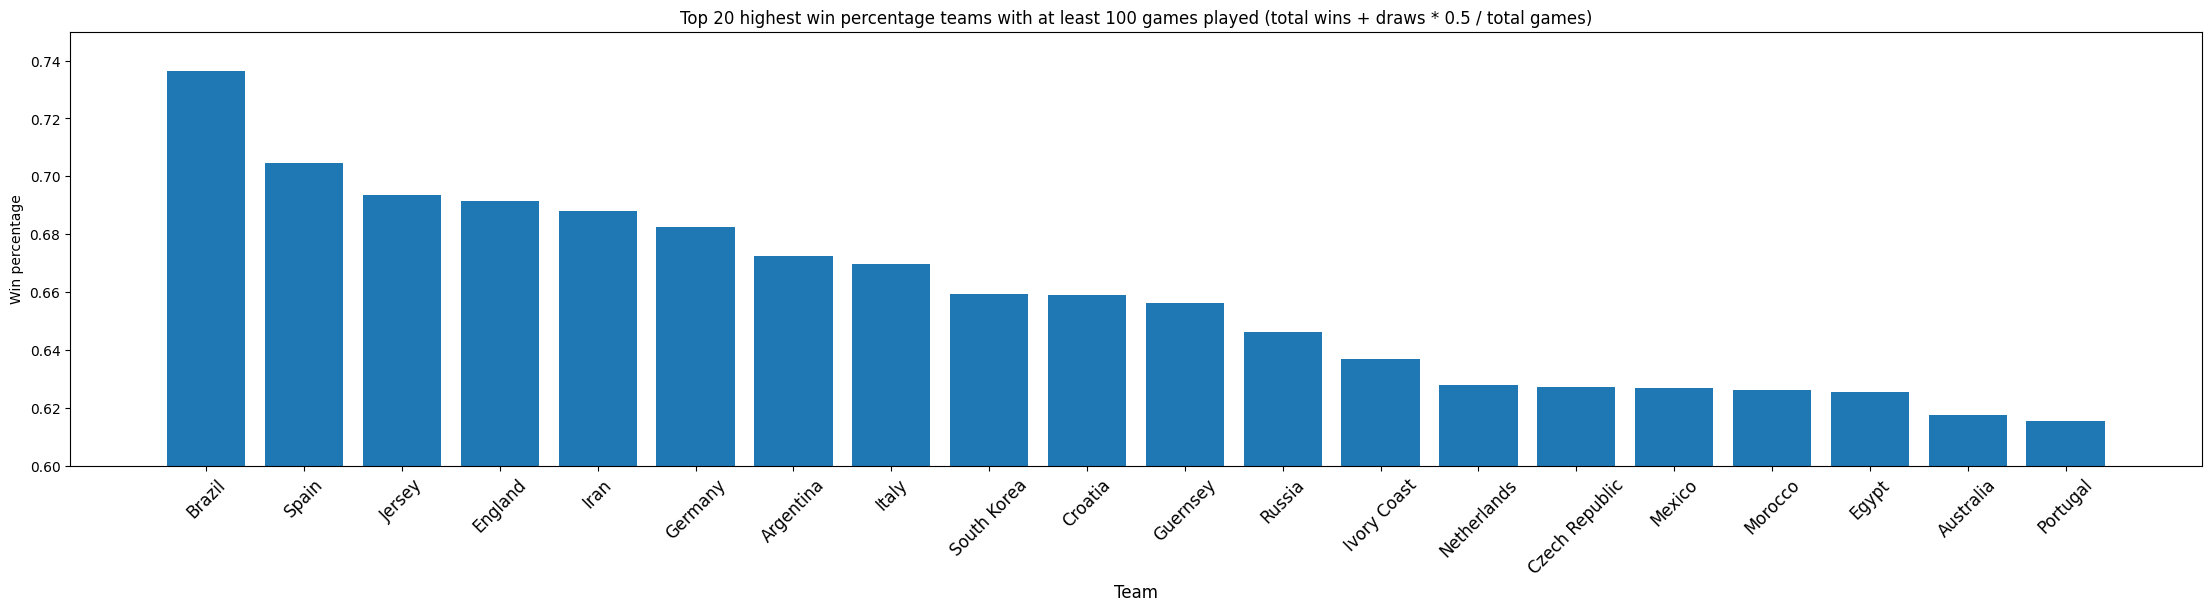

In [9]:
top_win_percentage = team_stats_new.query('games_played > 100')
top_win_percentage = top_win_percentage.groupby(
    top_win_percentage['name'])['win_percentage'].sum()
top_win_percentage = top_win_percentage.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(22, 6), layout='constrained')
ax.bar(top_win_percentage.index, top_win_percentage)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.set_ylim(0.6, 0.75)
ax.set_title('Top 20 highest win percentage teams with at least 100 games played (total wins + draws * 0.5 / total games)')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Win percentage')
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, fontsize=12)
plt.show()

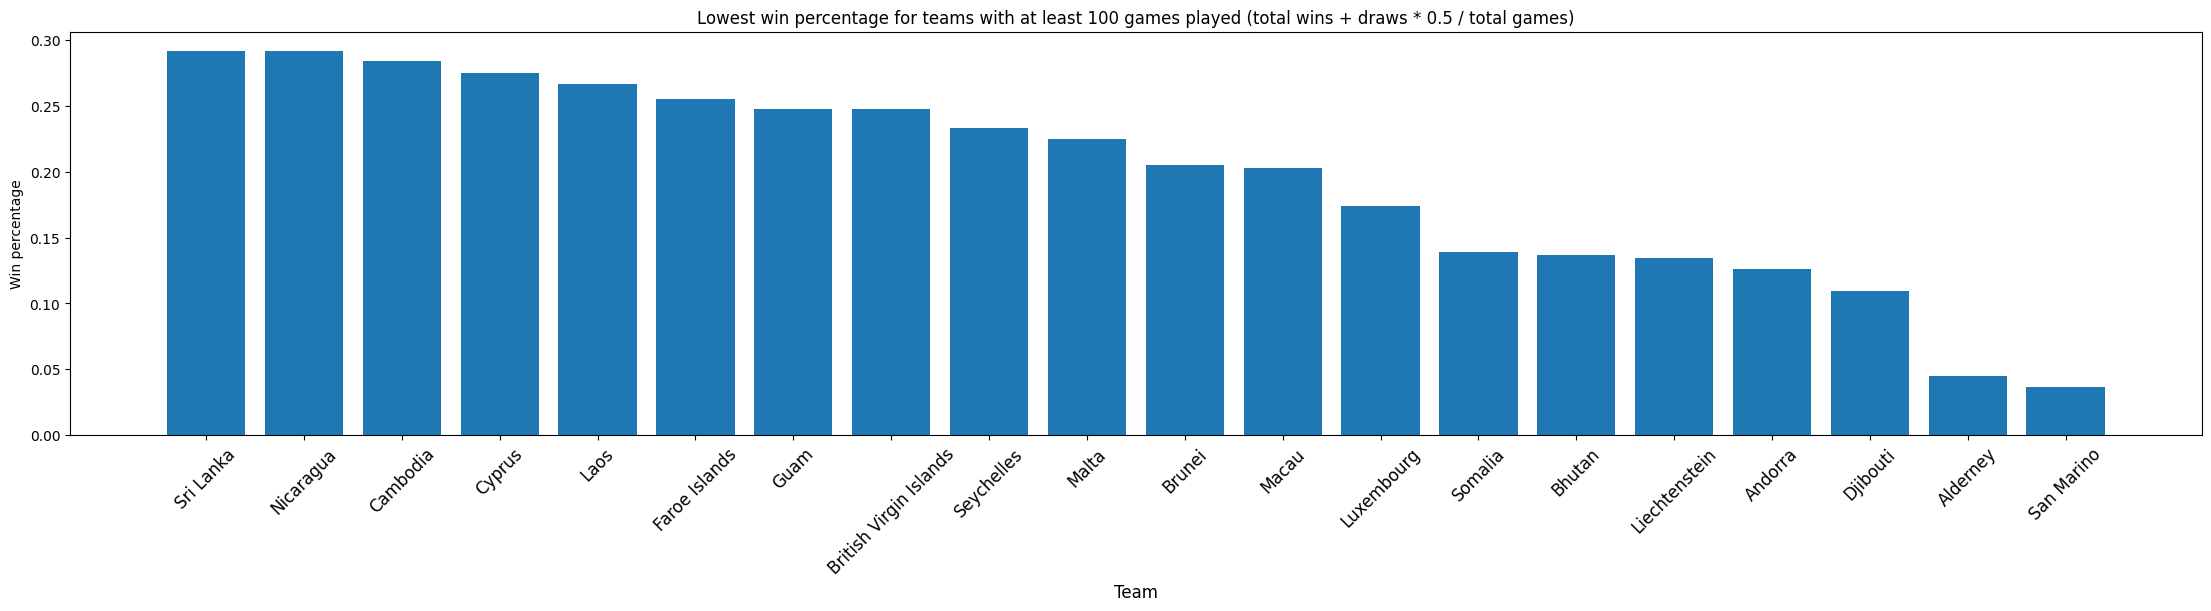

In [10]:
lowest_win_percentage = team_stats_new.query('games_played > 100')
lowest_win_percentage = lowest_win_percentage.groupby(
    lowest_win_percentage['name'])['win_percentage'].sum()
lowest_win_percentage = lowest_win_percentage.sort_values(ascending=False).tail(20)
fig, ax = plt.subplots(figsize=(22, 6), layout='constrained')
ax.bar(lowest_win_percentage.index, lowest_win_percentage)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.set_title('Lowest win percentage for teams with at least 100 games played (total wins + draws * 0.5 / total games)')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Win percentage')
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, fontsize=12)
plt.show()

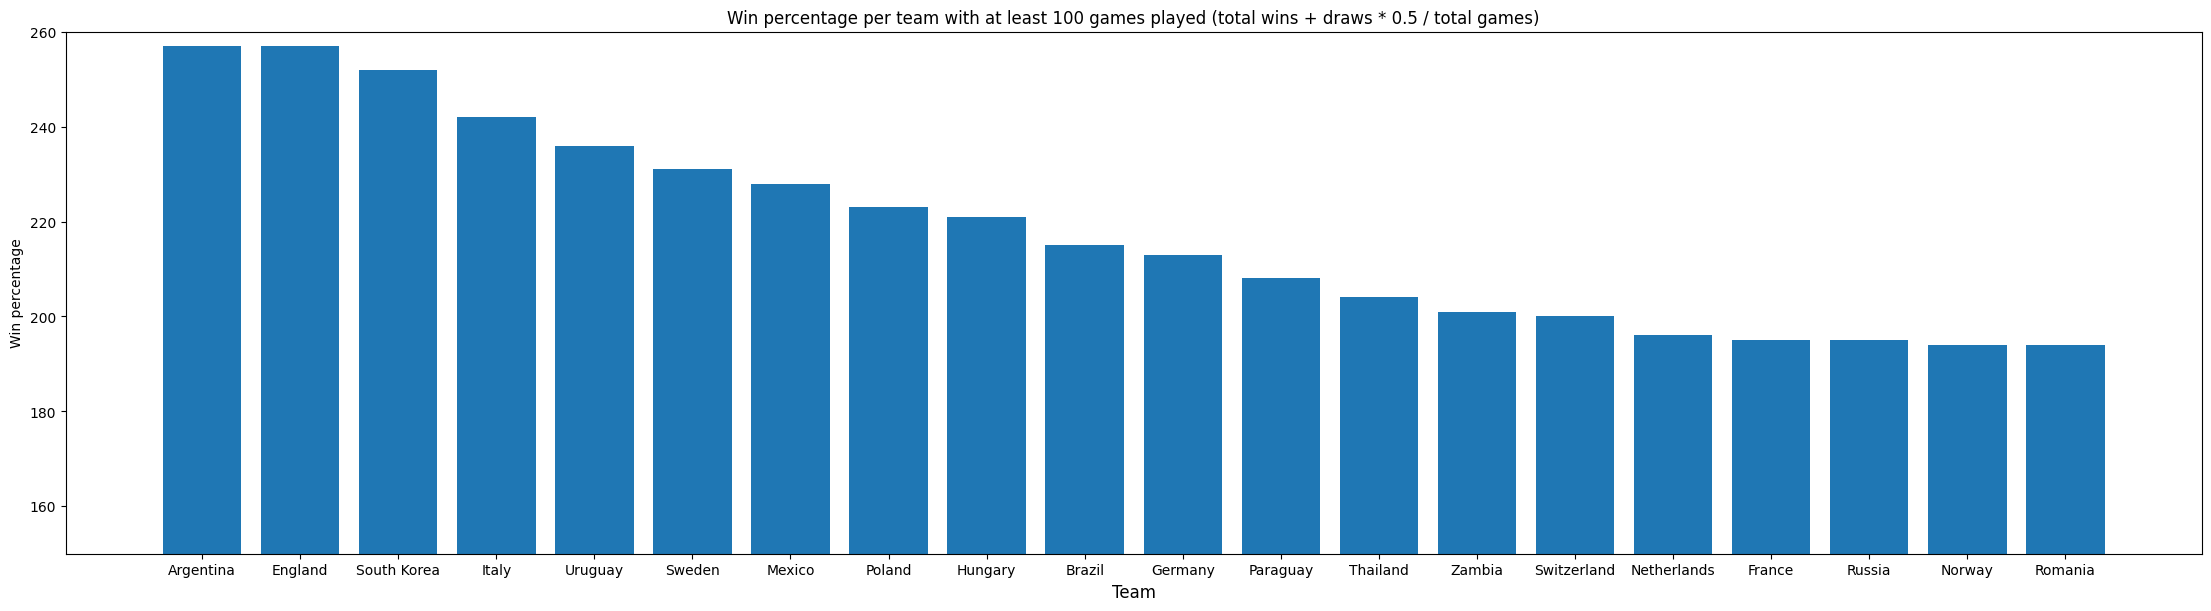

In [17]:
most_draws = team_stats_new.query('games_played > 100')
most_draws = most_draws.groupby(
    most_draws['name'])['total_draws'].sum()
most_draws = most_draws.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(22, 6), layout='constrained')
ax.bar(most_draws.index, most_draws)
ax.set_ylim(150, 260)
ax.set_title('Win percentage per team with at least 100 games played (total wins + draws * 0.5 / total games)')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Win percentage')
plt.show()

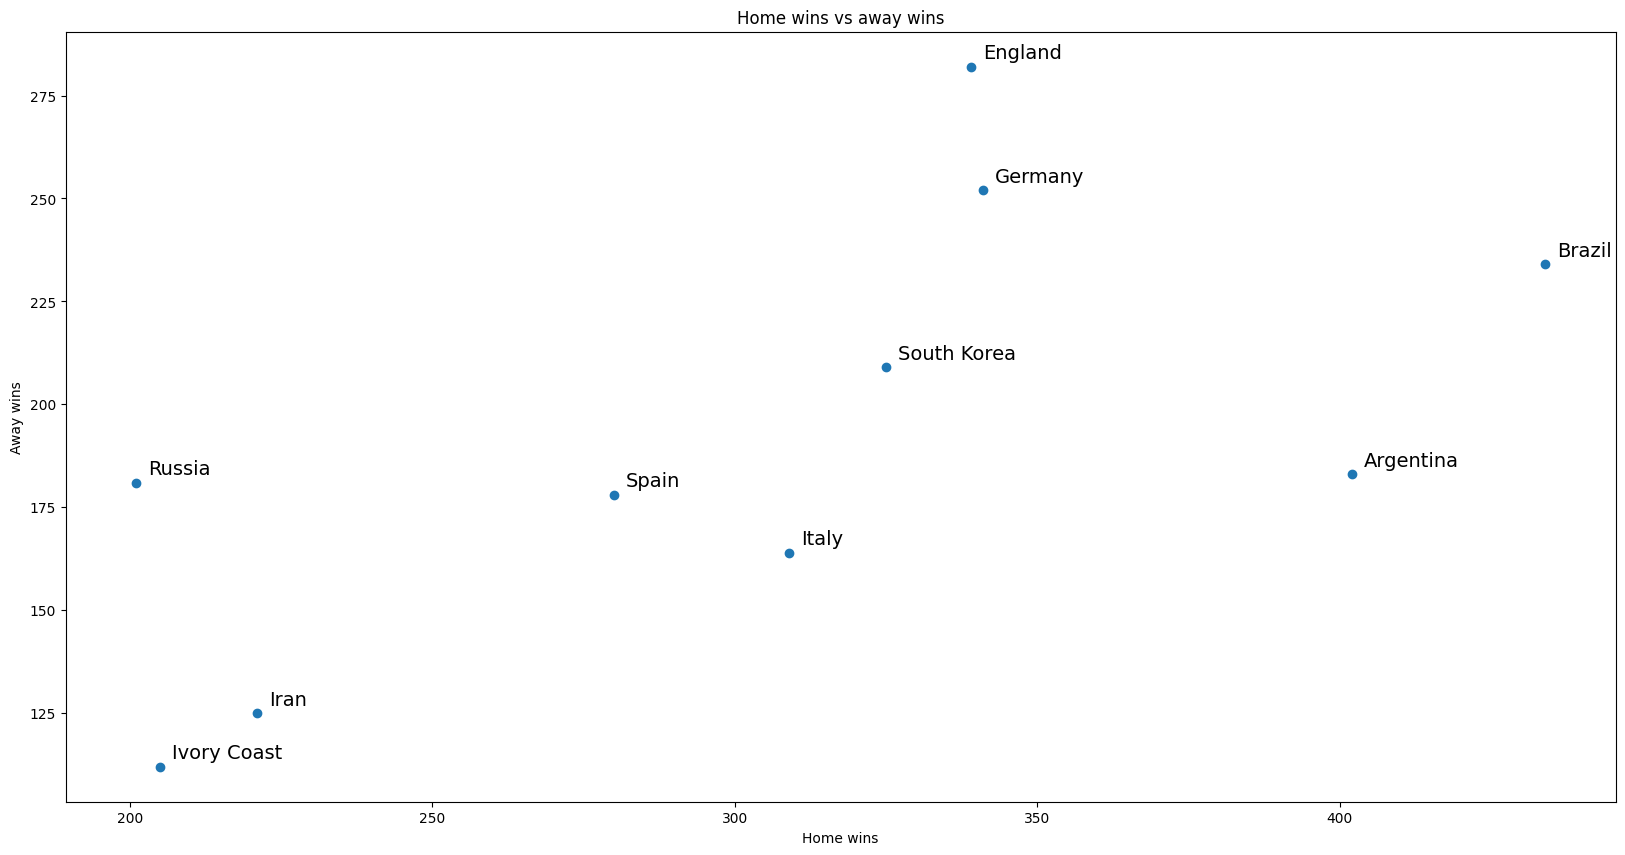

In [76]:
team_stats_sorted = team_stats_new.sort_values(by='win_percentage')
team_stats_sorted = team_stats_sorted.query('games_played > 500')
team_stats_sorted = team_stats_sorted.tail(10)
home_wins = team_stats_sorted.groupby(
    team_stats_sorted['name'])['home_wins'].sum().tail(10)
away_wins = team_stats_sorted.groupby(
    team_stats_sorted['name'])['away_wins'].sum().tail(10)

fig, ax = plt.subplots(figsize=(20, 10))
ax.scatter(home_wins, away_wins)
ax.set_title('Home wins vs away wins')
ax.set_xlabel('Home wins')
ax.set_ylabel('Away wins')

for i, txt in enumerate(home_wins.index):
    ax.annotate(txt, (home_wins.iloc[i], away_wins.iloc[i]), ((home_wins.iloc[i]+2), (away_wins.iloc[i]+2)),fontsize=14)
plt.show()

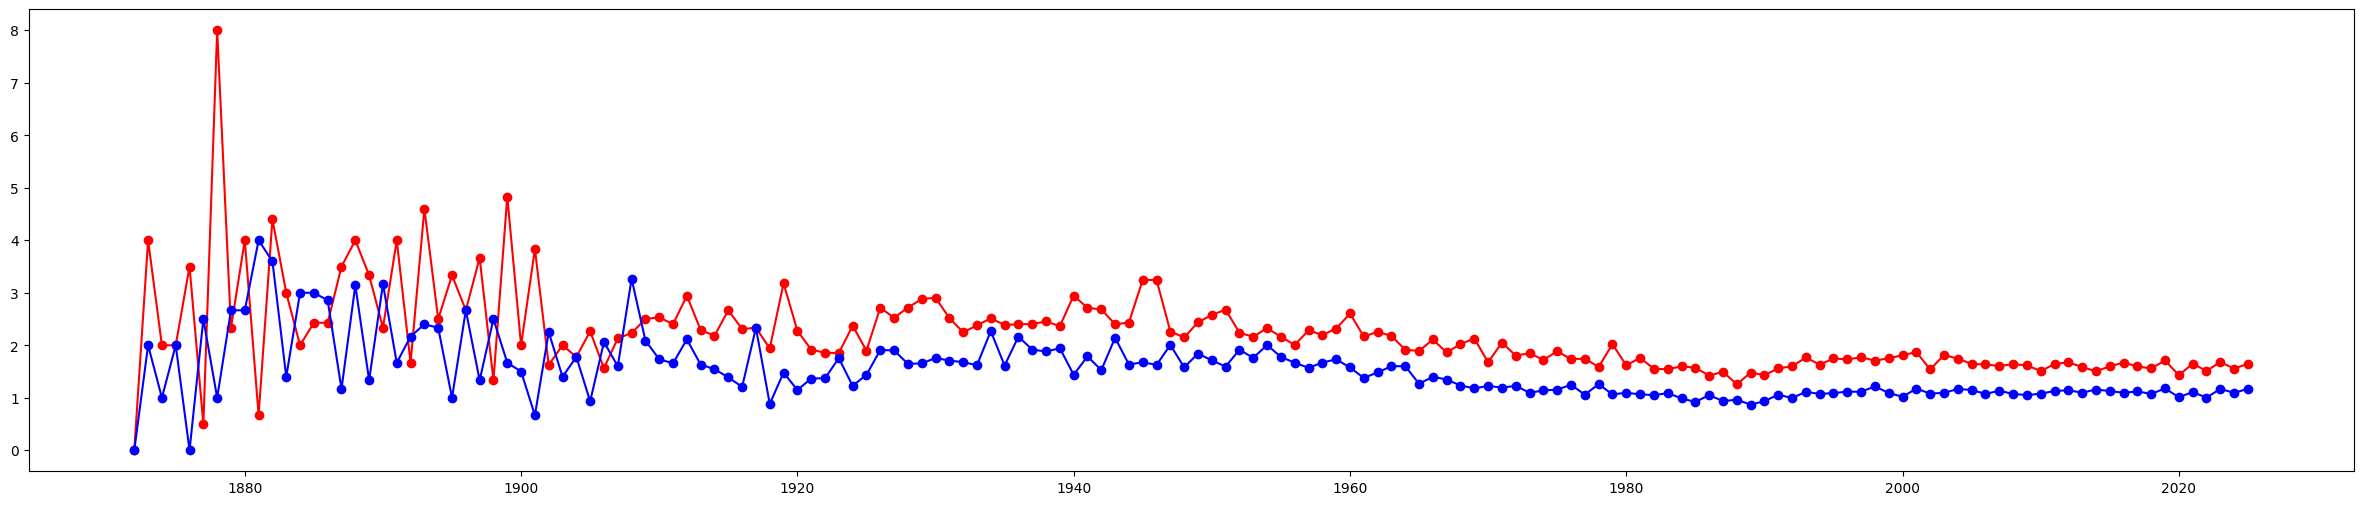

In [80]:

avg_home_goals = match_data.groupby(
    [match_data["date"].dt.year])["home_score"].mean()

avg_away_goals = match_data.groupby(
    [match_data["date"].dt.year])["away_score"].mean()
plt.figure(figsize=(30, 6))
plt.plot(avg_home_goals, label='home', color='red', marker='o')
plt.plot(avg_away_goals, label='away', color='blue', marker='o')

plt.show()

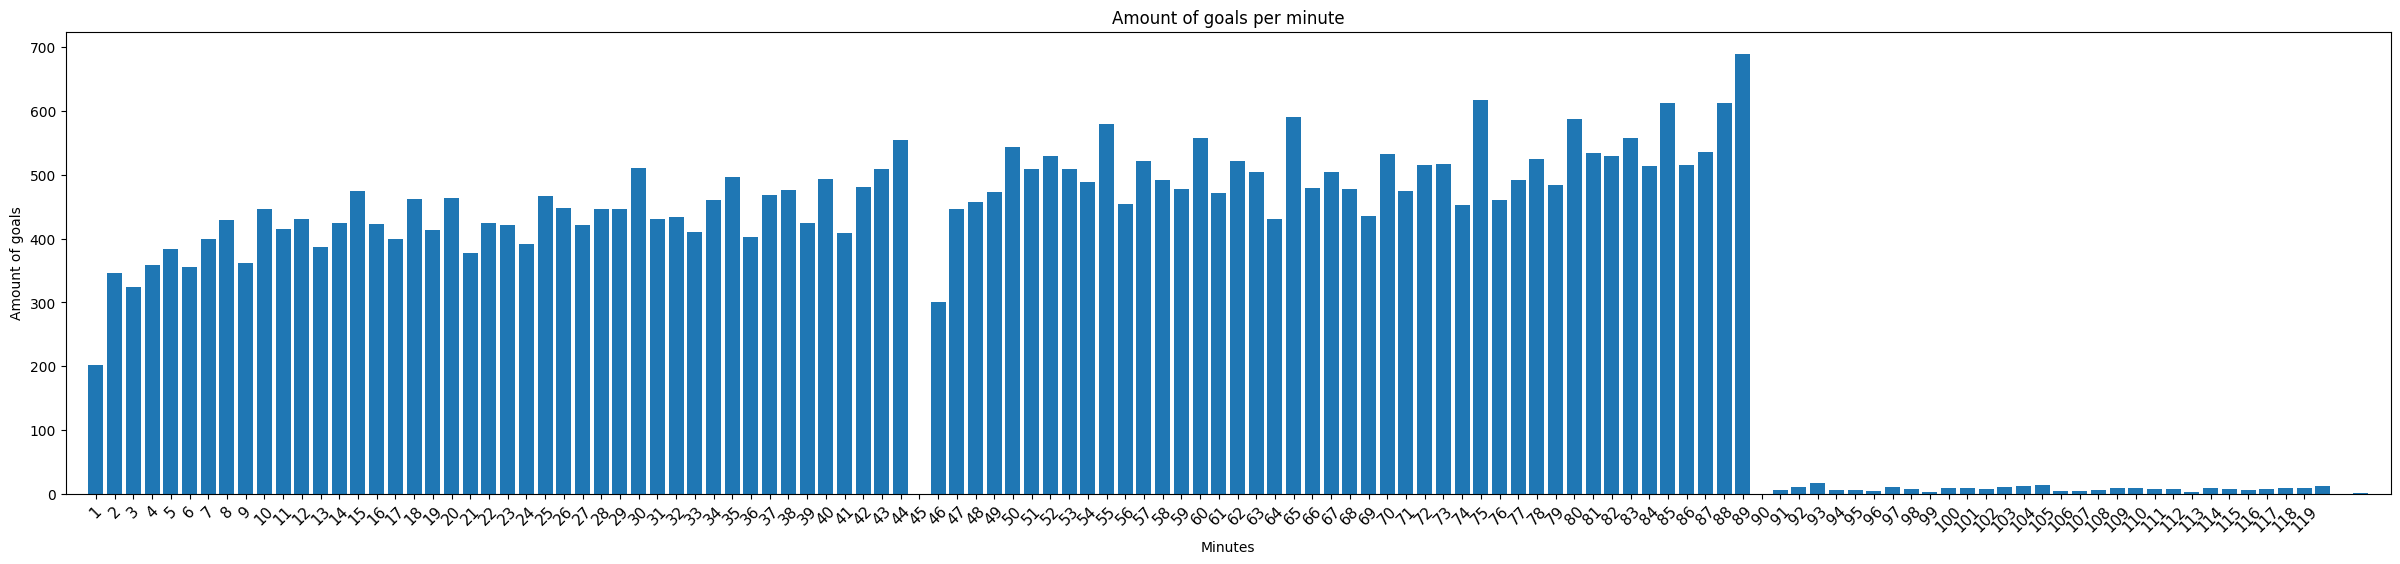

In [158]:
goalscorers_copy = goalscorers.copy()

total_goals = goalscorers_copy['team'].value_counts()
minutes = goalscorers_copy['minute'].value_counts()
#to omit 45 and 90 because it counts all goals 45+ and 90+ as goals in each time frame
minutes = minutes[minutes <900]
fig, ax = plt.subplots(figsize=(30, 6))
ax.bar(minutes.index, minutes)
ax.set_title('Amount of goals per minute')
ax.set_xlabel('Minutes')
ax.set_ylabel('Amount of goals')
ax.set_xticks(np.arange(1, 120, 1))
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.margins(x=0.01)
plt.show()

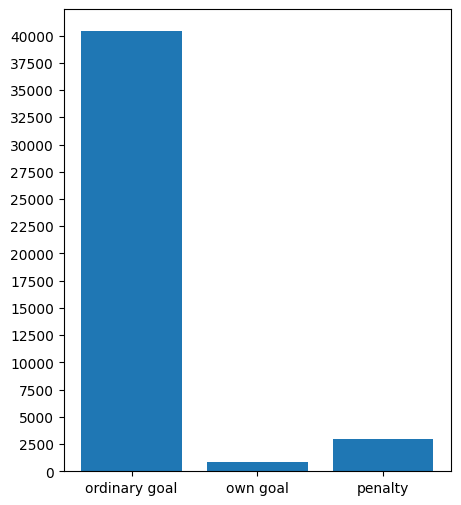

In [186]:
goalscorers_copy = goalscorers.copy()
own_goal = goalscorers_copy[goalscorers_copy['own_goal'] == True].value_counts().sum()
penalty = goalscorers_copy[goalscorers_copy['penalty'] == True].value_counts().sum()
ordinary_goal = goalscorers_copy[(goalscorers_copy['own_goal'] == False) & (goalscorers_copy['penalty'] == False)].value_counts().sum()
goal_types = {'ordinary goal': ordinary_goal, 'own goal': own_goal, 'penalty': penalty}
categories = goal_types.keys()
values = goal_types.values()
fig, ax = plt.subplots(figsize=(5, 6))
ax.bar(categories, values)
ax.set_yticks(np.arange(0, 42000, 2500))
plt.show()



In [205]:
penalty_goals = goalscorers.copy()

teams_penalty_goals = penalty_goals.groupby(['team'])
teams_penalty_goals.head(10)


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
...,...,...,...,...,...,...,...,...
41493,2021-10-07,Nigeria,Central African Republic,Central African Republic,Karl Namnganda,90.0,False,False
42185,2022-01-18,Ghana,Comoros,Comoros,El Fardou Ben Nabouhane,4.0,False,False
42186,2022-01-18,Ghana,Comoros,Comoros,Ahmed Mogni,62.0,False,False
42189,2022-01-18,Ghana,Comoros,Comoros,Ahmed Mogni,85.0,False,False


In [102]:
match_data_copy = match_data.copy()

match_data_copy['home_win'] = match_data_copy['home_score'] > match_data_copy['away_score']
match_data_copy['away_win'] = match_data_copy['home_score'] < match_data_copy['away_score']
match_data_copy['draw'] = match_data_copy['home_score'] == match_data_copy['away_score']
match_data_copy['year'] = match_data_copy['date'].dt.year
non_neutral_matches = match_data_copy[match_data_copy['neutral'] == False]
yearly_home_wins = non_neutral_matches.groupby(['year', 'home_team'])['home_win'].sum()
yearly_away_wins = non_neutral_matches.groupby(['year', 'away_team'])['away_win'].sum()
yearly_home_draws = non_neutral_matches.groupby(['year', 'home_team'])['draw'].sum()
yearly_away_draws = non_neutral_matches.groupby(['year', 'away_team'])['draw'].sum()
yearly_home_losses = non_neutral_matches.groupby(['year', 'home_team'])['away_win'].sum()
yearly_away_losses = non_neutral_matches.groupby(['year', 'away_team'])['home_win'].sum()
yearly_goals_scored_home = non_neutral_matches.groupby(['year', 'home_team'])['home_score'].sum()
yearly_goals_score_away = non_neutral_matches.groupby(['year', 'away_team'])['away_score'].sum()
yearly_goals_conceded_home = non_neutral_matches.groupby(['year', 'home_team'])['away_score'].sum()
yearly_goals_conceded_away = non_neutral_matches.groupby(['year', 'away_team'])['home_score'].sum()

home_stats = pd.DataFrame({
    'home_wins': yearly_home_wins,
    'home_draws': yearly_home_draws,
    'home_losses': yearly_home_losses,
    'home_goals_scored': yearly_goals_scored_home,
    'home_goals_conceded': yearly_goals_conceded_home
})
home_stats.rename_axis(index={'home_team': 'team'}, inplace=True)
away_stats = pd.DataFrame({
    'away_wins': yearly_away_wins,
    'away_draws': yearly_away_draws,
    'away_losses': yearly_away_losses,
    'away_goals_scored': yearly_goals_score_away,
    'away_goals_conceded': yearly_goals_conceded_away
})
away_stats.rename_axis(index={'away_team': 'team'}, inplace=True)


neutral_matches = match_data_copy[match_data_copy['neutral'] == True]
yearly_neutral_home_wins = neutral_matches.groupby(['year', 'home_team'])['home_win'].sum()
yearly_neutral_home_draws = neutral_matches.groupby(['year', 'home_team'])['draw'].sum()
yearly_neutral_home_losses = neutral_matches.groupby(['year', 'home_team'])['away_win'].sum()
yearly_neutral_goals_scored_home = neutral_matches.groupby(['year', 'home_team'])['home_score'].sum()
yearly_neutral_goals_conceded_home = neutral_matches.groupby(['year', 'home_team'])['away_score'].sum()
neutral_home = pd.DataFrame({
    'neutral_wins': yearly_neutral_home_wins,
    'neutral_draws': yearly_neutral_home_draws,
    'neutral_losses': yearly_neutral_home_losses,
    'neutral_goals_scored': yearly_neutral_goals_scored_home,
    'neutral_goals_conceded': yearly_neutral_goals_conceded_home
})
neutral_home.rename_axis(index={'home_team': 'team'}, inplace=True)

yearly_neutral_away_wins = neutral_matches.groupby(['year', 'away_team'])['away_win'].sum()
yearly_neutral_away_draws = neutral_matches.groupby(['year', 'away_team'])['draw'].sum()
yearly_neutral_away_losses = neutral_matches.groupby(['year', 'away_team'])['home_win'].sum()
yearly_neutral_goals_score_away = neutral_matches.groupby(['year', 'away_team'])['away_score'].sum()
yearly_neutral_goals_conceded_away = neutral_matches.groupby(['year', 'away_team'])['home_score'].sum()
neutral_away = pd.DataFrame({
    'neutral_wins': yearly_neutral_away_wins,
    'neutral_draws': yearly_neutral_away_draws,
    'neutral_losses': yearly_neutral_away_losses,
    'neutral_goals_scored': yearly_neutral_goals_score_away,
    'neutral_goals_conceded': yearly_neutral_goals_conceded_away
})
neutral_away.rename_axis(index={'away_team': 'team'}, inplace=True)

neutral_stats = (neutral_home + neutral_away).fillna(0)


team_yearly_stats = pd.merge(home_stats, away_stats, left_index=True, right_index=True, how='outer').fillna(0)
team_yearly_stats = pd.merge(team_yearly_stats, neutral_stats, left_index=True, right_index=True, how='outer').fillna(0)
team_yearly_stats['total_goals_scored'] = (team_yearly_stats['home_goals_scored'] + team_yearly_stats['away_goals_scored'] + team_yearly_stats['neutral_goals_scored']).fillna(0)
team_yearly_stats['total_goals_conceded'] = (team_yearly_stats['home_goals_conceded'] + team_yearly_stats['away_goals_conceded'] +
 team_yearly_stats['neutral_goals_conceded']).fillna(0)
team_yearly_stats['total_goal_difference'] = (team_yearly_stats['total_goals_scored'] - team_yearly_stats['total_goals_conceded']).fillna(0)
team_yearly_stats['total_points'] = (team_yearly_stats['total_goals_scored'] * 3 + team_yearly_stats['total_goal_difference'] * 1).fillna(0)
team_yearly_stats['total_wins'] = (team_yearly_stats['home_wins'] + team_yearly_stats['away_wins'] + team_yearly_stats['neutral_wins']).fillna(0)
team_yearly_stats['total_draws'] = (team_yearly_stats['home_draws'] + team_yearly_stats['away_draws'] + team_yearly_stats['neutral_draws']).fillna(0)
team_yearly_stats['total_loses'] = (team_yearly_stats['home_losses'] + team_yearly_stats['away_losses'] + team_yearly_stats['neutral_losses']).fillna(0)
team_yearly_stats['total_games_played'] = (team_yearly_stats['total_wins'] + team_yearly_stats['total_draws'] + team_yearly_stats['total_loses']).fillna(0)
team_yearly_stats['win_percentage'] = (team_yearly_stats['total_wins'] / team_yearly_stats['total_games_played']).fillna(0)
team_yearly_stats['draw_percentage'] = (team_yearly_stats['total_draws'] / team_yearly_stats['total_games_played']).fillna(0)
team_yearly_stats['loss_percentage'] = (team_yearly_stats['total_loses'] / team_yearly_stats['total_games_played']).fillna(0)

team_yearly_stats.to_csv('team_yearly_stats.csv')

In [97]:
yearly_team_stats = pd.read_csv('team_yearly_stats.csv')

<BarContainer object of 10 artists>

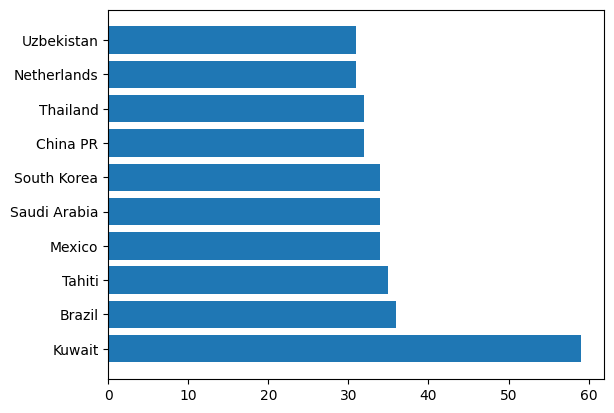

In [101]:
pop_data_1998 = yearly_team_stats[yearly_team_stats['year'] == 1998]
top_countries = pop_data_1998.nlargest(10, 'total_goals_scored')
plt.barh(top_countries['team'], top_countries['total_goals_scored'])